In [1]:
import pandas as pd
from src.eda import data_profiling
from src.dictionaries import dictionary

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def split_data_by_clusters(df, cluster_col):
    """
    Tách DataFrame gốc thành dictionary các DataFrame con theo cluster.
    """
    unique_clusters = sorted(df[cluster_col].unique())
    cluster_dict = {}
    for cid in unique_clusters:
        name = f"cluster_{cid}" if cid != -1 else "cluster_noise"
        cluster_dict[name] = df[df[cluster_col] == cid].copy()
        print(f"  + {name.ljust(15)}: {len(cluster_dict[name])} dòng")
    return cluster_dict

def analyze_and_plot_df(df):
    sns.set_theme(style="whitegrid")

    for col in df.columns:
        print(f"\n" + "="*50)
        print(f"ĐANG PHÂN TÍCH CỘT: '{col}'")
        print("="*50)

        if pd.api.types.is_numeric_dtype(df[col]):
            print(df[col].describe())

            plt.figure(figsize=(8, 4))
            sns.boxplot(x=df[col], color="skyblue")
            plt.title(f"Box Plot of {col}", fontsize=14, fontweight='bold')
            plt.xlabel(col)
            plt.tight_layout()
            plt.show()

        else:
            value_counts = df[col].value_counts()
            print(f"Số lượng chi tiết từng nhóm:")
            print(value_counts)

            if len(value_counts) > 5:
                print(f"⚠️ Cột này có {len(value_counts)} nhóm. Chỉ vẽ Bar chart.")

                sns.barplot(x=value_counts.values, y=value_counts.index, palette="viridis")

                plt.title(f"Horizontal Bar Chart of {col}", fontsize=14, fontweight='bold')
                plt.xlabel("Count")  # Trục X bây giờ hiển thị số lượng
                plt.ylabel(col)      # Trục Y hiển thị tên các nhóm

                plt.tight_layout()
                plt.show()
            else:
                fig, axes = plt.subplots(1, 2, figsize=(14, 6))

                sns.barplot(
                        x=value_counts.values,
                        y=value_counts.index,
                        ax=axes[0],
                        palette="pastel"
                    )
                axes[0].set_title(f"Bar Chart (Count) - {col}", fontsize=12, fontweight='bold')
                axes[0].set_xlabel("Count")  # Lúc này số lượng nằm ở trục X
                axes[0].set_ylabel(col)      # Tên biến nằm ở trục Y

                axes[1].pie(value_counts.values, labels=value_counts.index, autopct='%1.1f%%',
                            startangle=140, colors=sns.color_palette("pastel", len(value_counts)))
                axes[1].set_title(f"Pie Chart (Percentage) - {col}", fontsize=12, fontweight='bold')

                plt.tight_layout()
                plt.show()

In [3]:
d = dictionary()
GenderID = d.GenderID
SPSS_Regio5 = d.SPSS_Regio5
BAS_werkzaamheid_resp = d.BAS_werkzaamheid_resp
AFG_sk2015= d.AFG_sk2015
BAS_voltooide_opleiding8_resp = d.BAS_voltooide_opleiding8_resp
SPSS_Lifestage = d.SPSS_Lifestage
BAS_bruto_jaarinkomen = d.BAS_bruto_jaarinkomen

In [4]:
data = pd.read_csv("../../resources/model/clustering/result/clustering_result.csv")

data['GenderID'] = data['GenderID'].map(d.GenderID)
data['SPSS_Regio5'] = data['SPSS_Regio5'].map(d.SPSS_Regio5)
data['BAS_werkzaamheid_resp'] = data['BAS_werkzaamheid_resp'].map(d.BAS_werkzaamheid_resp)
data['AFG_sk2015'] = data['AFG_sk2015'].map(d.AFG_sk2015)
data['BAS_voltooide_opleiding8_resp'] = data['BAS_voltooide_opleiding8_resp'].map(d.BAS_voltooide_opleiding8_resp)
data['SPSS_Lifestage'] = data['SPSS_Lifestage'].map(d.SPSS_Lifestage)
data['BAS_bruto_jaarinkomen'] = data['BAS_bruto_jaarinkomen'].map(d.BAS_bruto_jaarinkomen)


In [5]:
data.to_excel("D:/clustering_mapping_result.xlsx", index=False)

In [23]:
cluster_dict = split_data_by_clusters(data, "final_label")

  + cluster_noise  : 268 dòng
  + cluster_0      : 4107 dòng
  + cluster_1      : 2533 dòng
  + cluster_2      : 1167 dòng


Phân tích bộ dữ liệu: cluster_noise

ĐANG PHÂN TÍCH CỘT: 'Unnamed: 0'
count     268.000000
mean     4590.925373
std      2846.507735
min         9.000000
25%      2184.750000
50%      4160.500000
75%      7242.250000
max      9677.000000
Name: Unnamed: 0, dtype: float64


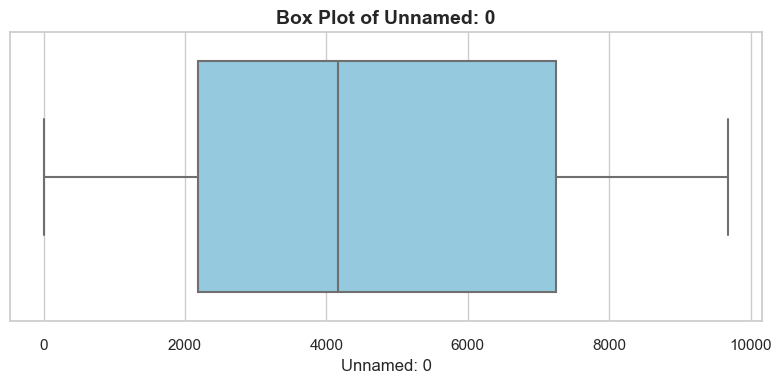


ĐANG PHÂN TÍCH CỘT: 'UserID'
count     268.000000
mean     4911.141791
std      3043.577608
min         8.000000
25%      2331.000000
50%      4475.000000
75%      7749.250000
max      9665.000000
Name: UserID, dtype: float64


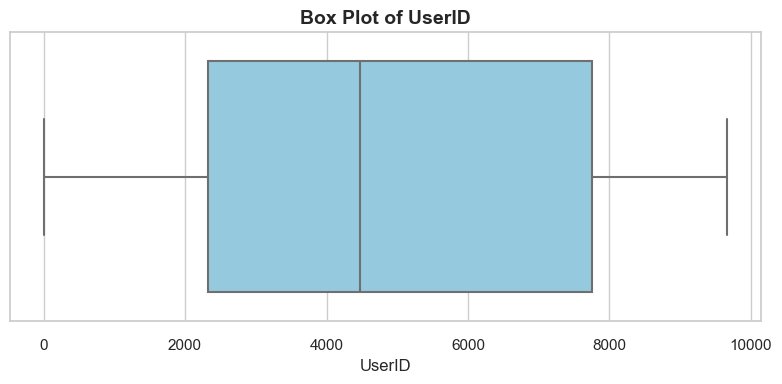


ĐANG PHÂN TÍCH CỘT: 'GenderID'
Số lượng chi tiết từng nhóm:
GenderID
Female    154
Male      114
Name: count, dtype: int64


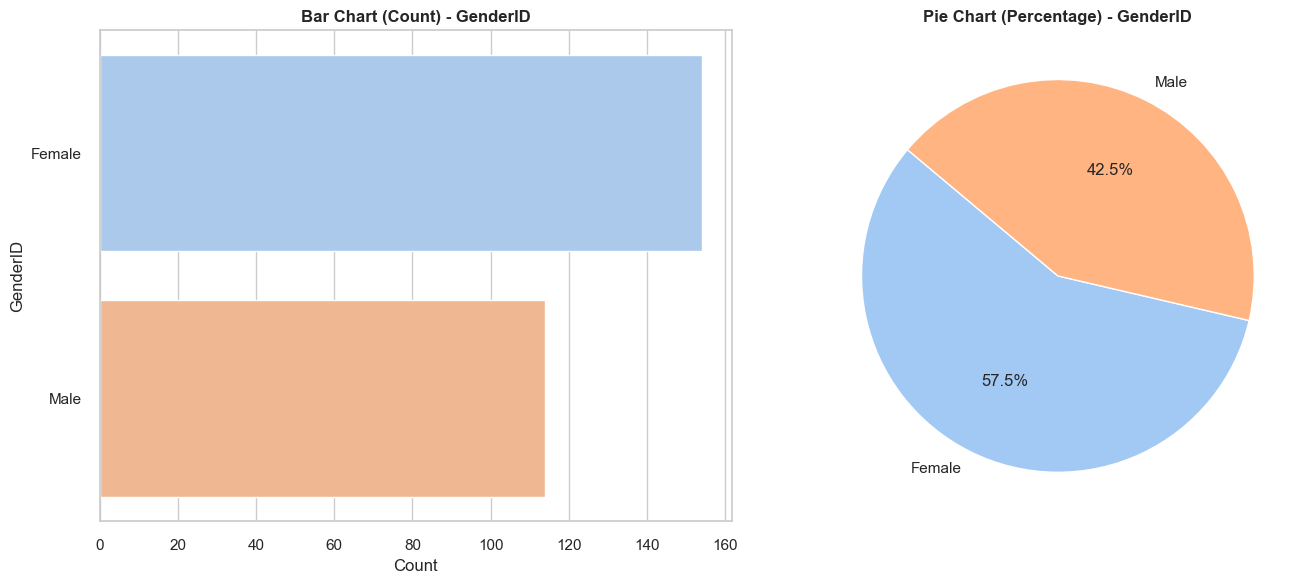


ĐANG PHÂN TÍCH CỘT: 'Age'
count    268.000000
mean      38.343284
std       13.841859
min       18.000000
25%       25.000000
50%       40.000000
75%       47.000000
max       77.000000
Name: Age, dtype: float64


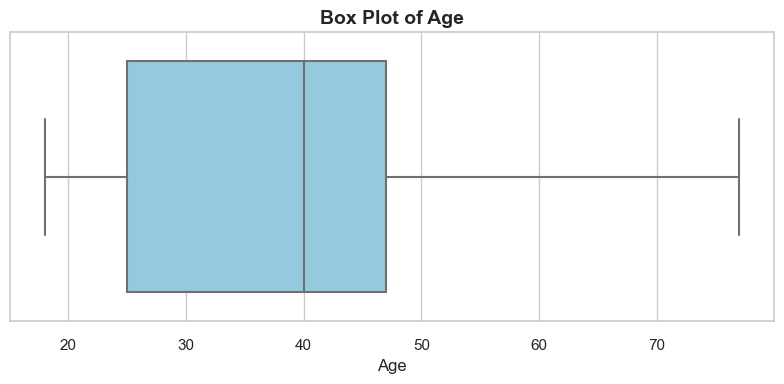


ĐANG PHÂN TÍCH CỘT: 'SPSS_Regio5'
Số lượng chi tiết từng nhóm:
SPSS_Regio5
West (1 excluded)                 83
East                              72
South                             53
North                             31
Amsterdam, Rotterdam, Den Haag    29
Name: count, dtype: int64


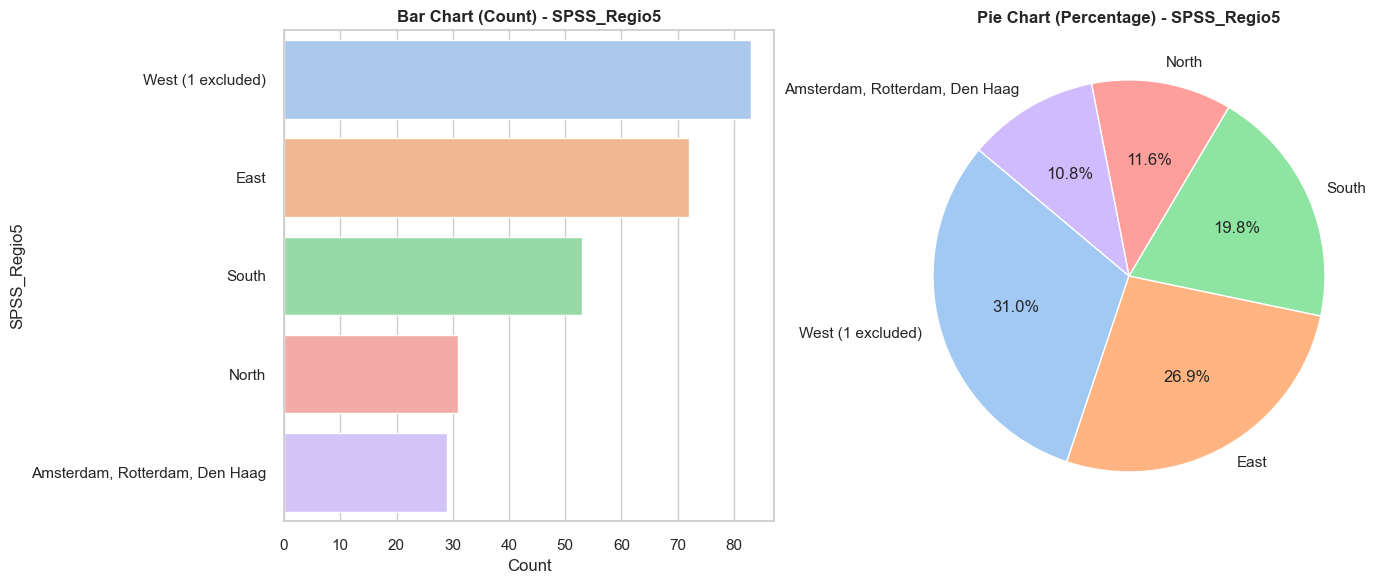


ĐANG PHÂN TÍCH CỘT: 'BAS_huishoudgrootte'
count    268.000000
mean       5.018657
std        1.714563
min        1.000000
25%        4.000000
50%        5.000000
75%        6.000000
max       11.000000
Name: BAS_huishoudgrootte, dtype: float64


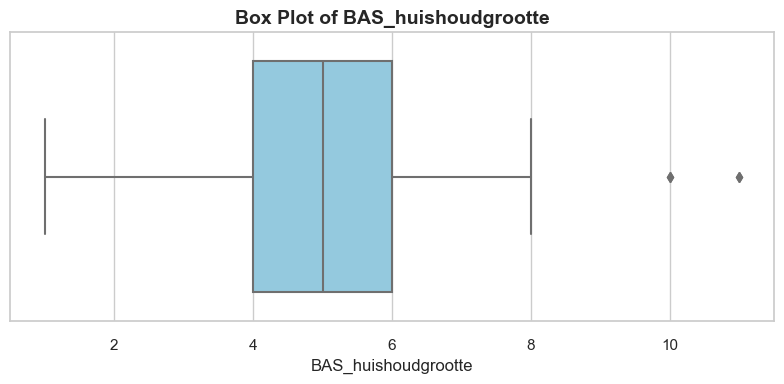


ĐANG PHÂN TÍCH CỘT: 'BAS_werkzaamheid_resp'
Số lượng chi tiết từng nhóm:
BAS_werkzaamheid_resp
salaried employment          78
housewife/houseman/other     73
student/scholar              57
incapacitated                12
unemployed / job seeker      12
(early) retirement           10
working for the governent     9
don't know                    9
entrepreneur                  6
social assistance benefit     2
Name: count, dtype: int64
⚠️ Cột này có 10 nhóm. Chỉ vẽ Bar chart.


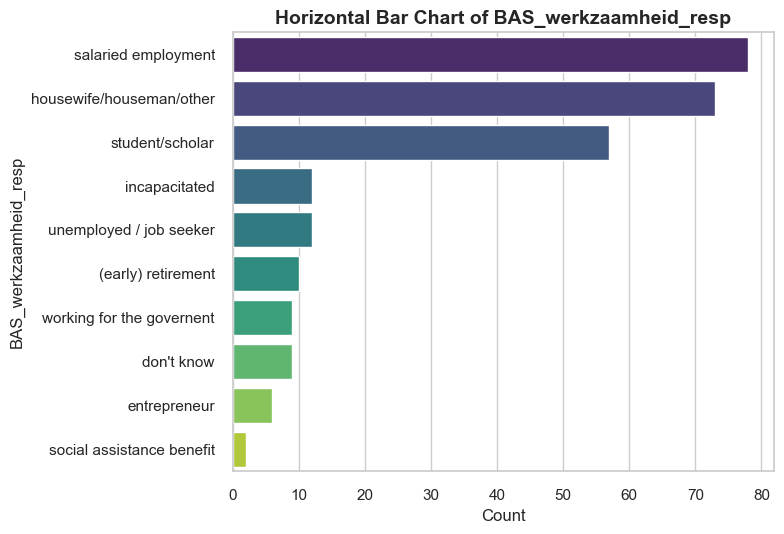


ĐANG PHÂN TÍCH CỘT: 'BAS_bruto_jaarinkomen'
Số lượng chi tiết từng nhóm:
BAS_bruto_jaarinkomen
Don't know / Don't want to say                       72
€40.000 <= 67.000 (between 1 and 2 times average)    45
€12.900 <= 27.000 (below average)                    39
€33.500 <= 40.000 (average)                          32
€27.000 <= 33.500 (almost average)                   28
< €12.900 (minimum)                                  22
€67.000 <= 79.900 (2 times average)                  16
> 79.900 (above 2 times average)                     14
Name: count, dtype: int64
⚠️ Cột này có 8 nhóm. Chỉ vẽ Bar chart.


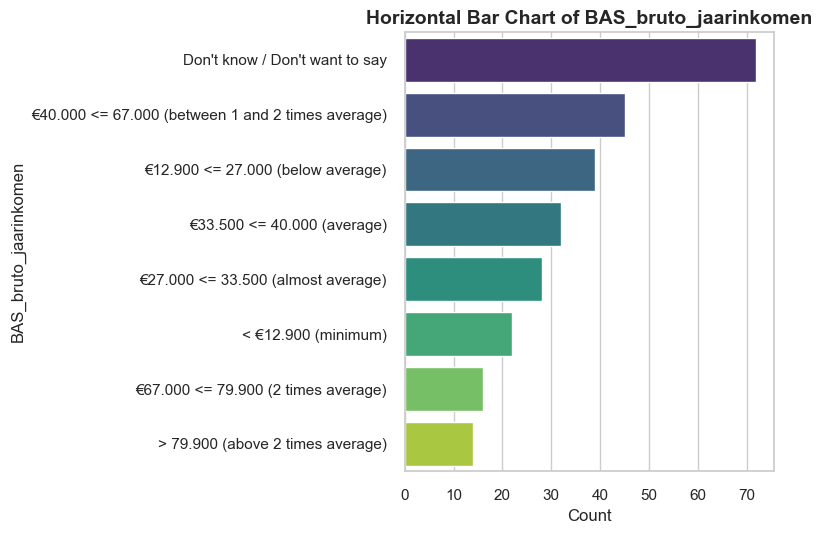


ĐANG PHÂN TÍCH CỘT: 'afg_kinderen_huishouden'
count    268.000000
mean       1.899254
std        1.815745
min        0.000000
25%        0.000000
50%        1.000000
75%        3.000000
max        8.000000
Name: afg_kinderen_huishouden, dtype: float64


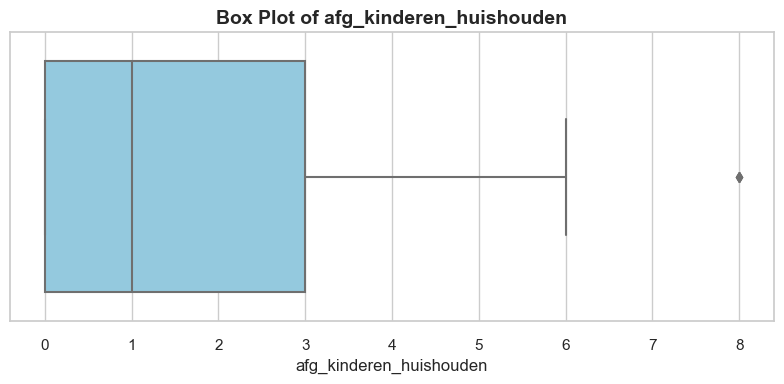


ĐANG PHÂN TÍCH CỘT: 'AFG_sk2015'
Số lượng chi tiết từng nhóm:
AFG_sk2015
b2    62
a     59
c     58
b1    49
d     40
Name: count, dtype: int64


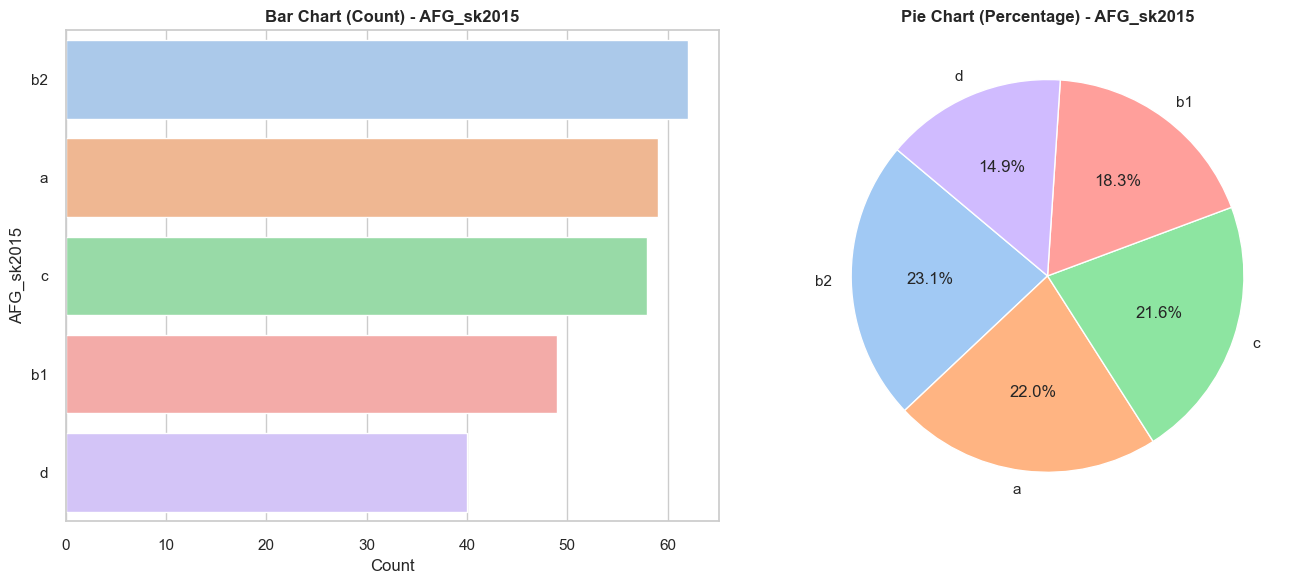


ĐANG PHÂN TÍCH CỘT: 'BAS_voltooide_opleiding8_resp'
Số lượng chi tiết từng nhóm:
BAS_voltooide_opleiding8_resp
MBO 2, 3, 4 of MBO voor 1998                                                           72
HBO of universitair bachelor/kandidaats                                                34
HAVO of VWO (met diploma afgerond) / HBS/ MMS                                          32
LBO / VMBO (kader- of beroepsgericht) / MBO 1 / VBO                                    26
MAVO/ HAVO of VWO (overgegaan naar 4e klas)/ VMBO (theoretisch of gemengd) / (M)ULO    24
HBO of universitair master/doctoraal/postdoctoraal                                     19
HBO of universitair propedeuse                                                         18
Geen of basisonderwijs                                                                 13
Name: count, dtype: int64
⚠️ Cột này có 8 nhóm. Chỉ vẽ Bar chart.


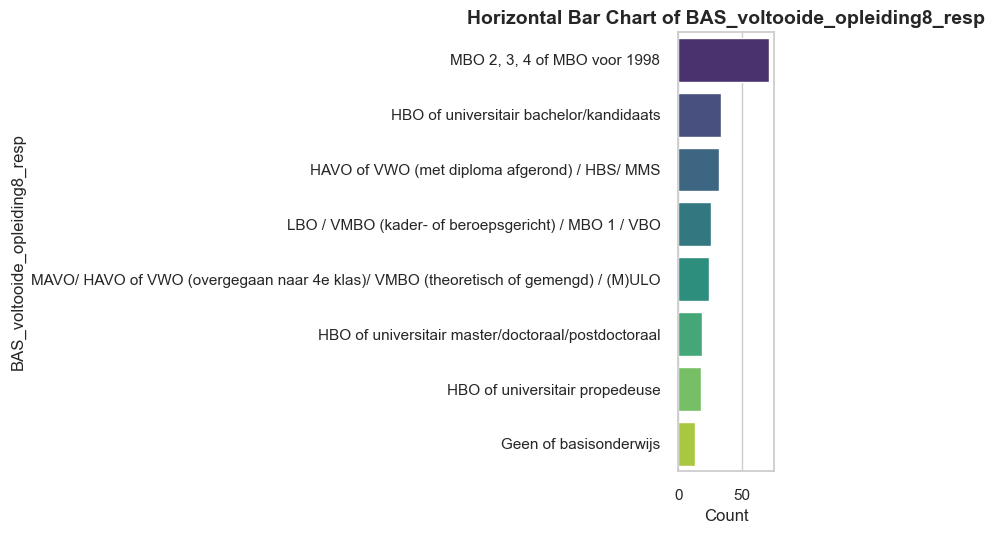


ĐANG PHÂN TÍCH CỘT: 'SPSS_Lifestage'
Số lượng chi tiết từng nhóm:
SPSS_Lifestage
Mature Families                     101
Young Families                       48
Established Families                 44
Single Parents, adult child(ren)     43
Single Parents, child(ren)           29
Young Singles                         2
unknown                               1
Name: count, dtype: int64
⚠️ Cột này có 7 nhóm. Chỉ vẽ Bar chart.


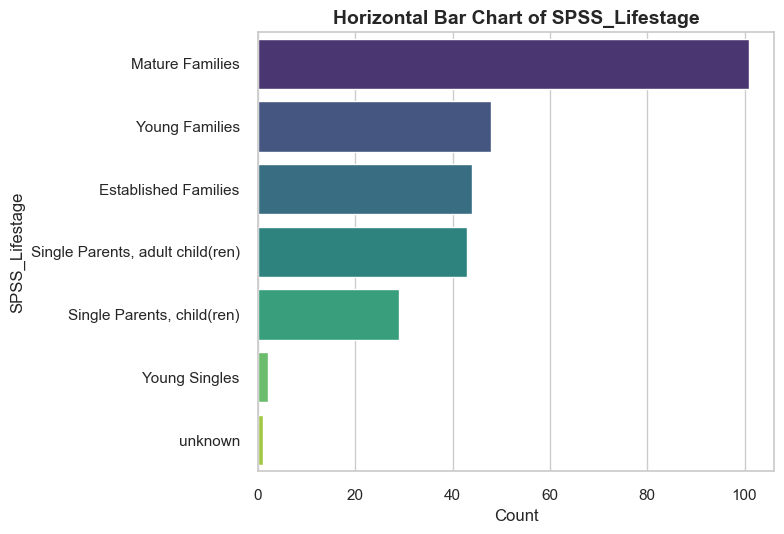


ĐANG PHÂN TÍCH CỘT: 'dbscan_labels'
count    268.0
mean      -1.0
std        0.0
min       -1.0
25%       -1.0
50%       -1.0
75%       -1.0
max       -1.0
Name: dbscan_labels, dtype: float64


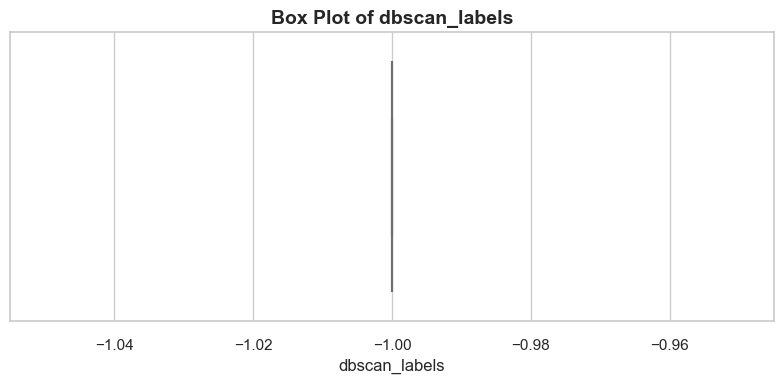


ĐANG PHÂN TÍCH CỘT: 'final_label'
count    268.0
mean      -1.0
std        0.0
min       -1.0
25%       -1.0
50%       -1.0
75%       -1.0
max       -1.0
Name: final_label, dtype: float64


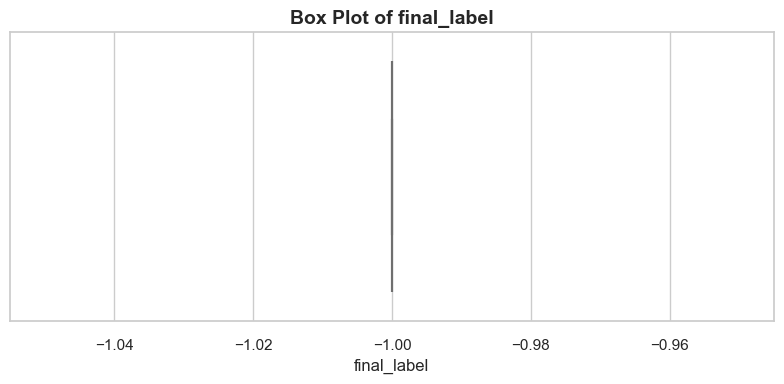

Phân tích bộ dữ liệu: cluster_0

ĐANG PHÂN TÍCH CỘT: 'Unnamed: 0'
count    4107.000000
mean     4951.490869
std      2703.147331
min         2.000000
25%      2656.000000
50%      4858.000000
75%      7214.500000
max      9676.000000
Name: Unnamed: 0, dtype: float64


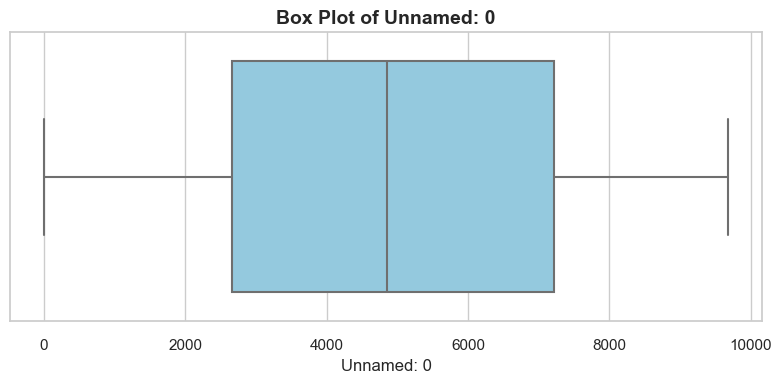


ĐANG PHÂN TÍCH CỘT: 'UserID'
count    4107.000000
mean     4685.716338
std      2573.094316
min         1.000000
25%      2530.000000
50%      4524.000000
75%      6843.000000
max      9678.000000
Name: UserID, dtype: float64


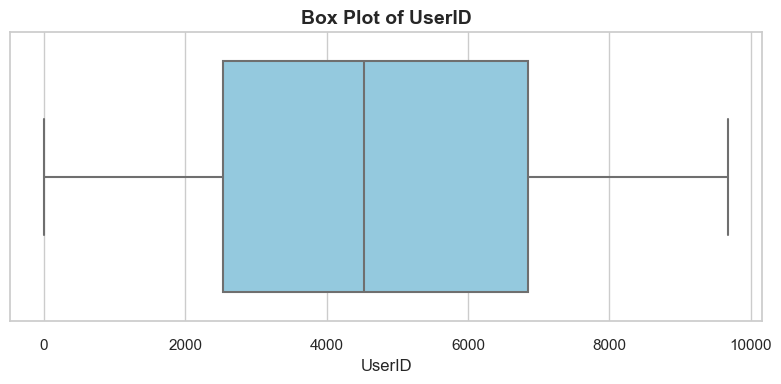


ĐANG PHÂN TÍCH CỘT: 'GenderID'
Số lượng chi tiết từng nhóm:
GenderID
Female    2257
Male      1850
Name: count, dtype: int64


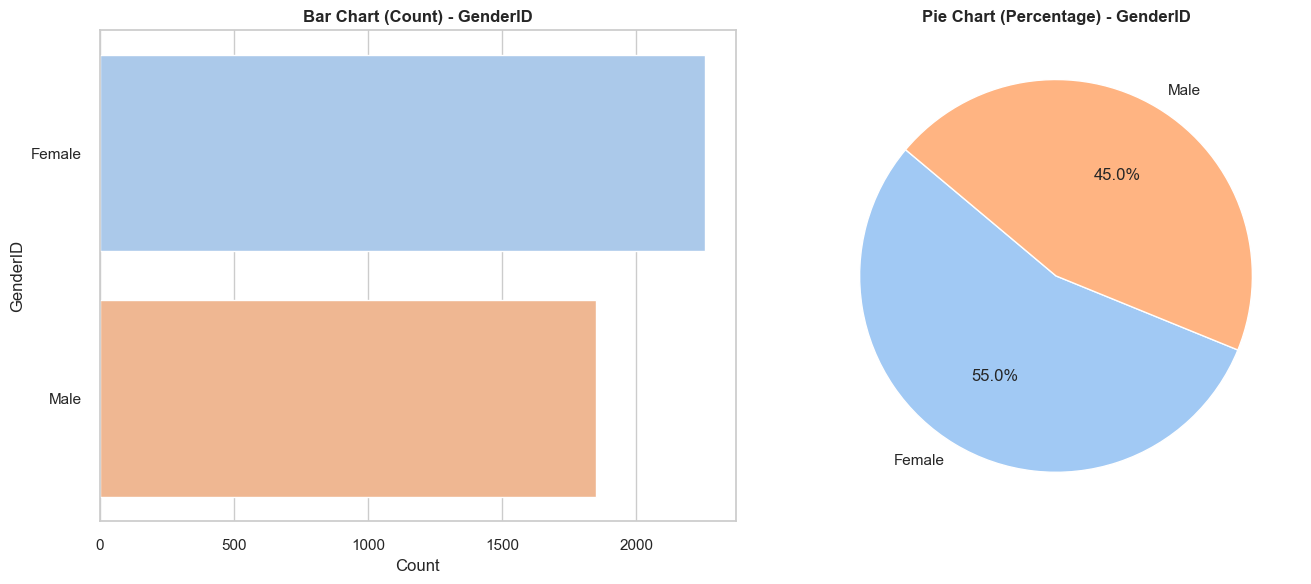


ĐANG PHÂN TÍCH CỘT: 'Age'
count    4107.000000
mean       63.902362
std         9.201906
min        38.000000
25%        57.000000
50%        64.000000
75%        71.000000
max        94.000000
Name: Age, dtype: float64


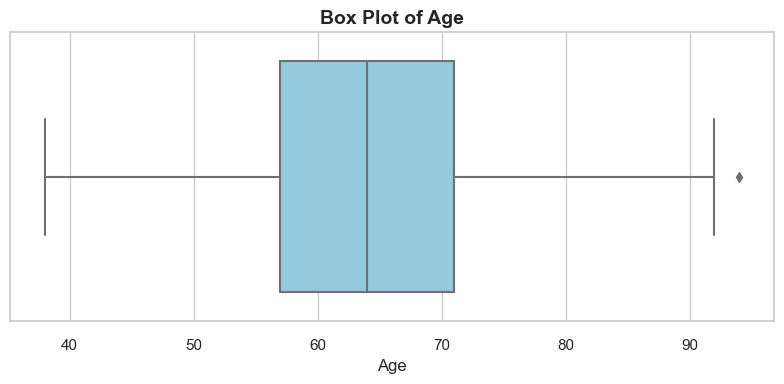


ĐANG PHÂN TÍCH CỘT: 'SPSS_Regio5'
Số lượng chi tiết từng nhóm:
SPSS_Regio5
West (1 excluded)                 1140
South                             1128
East                               803
Amsterdam, Rotterdam, Den Haag     557
North                              479
Name: count, dtype: int64


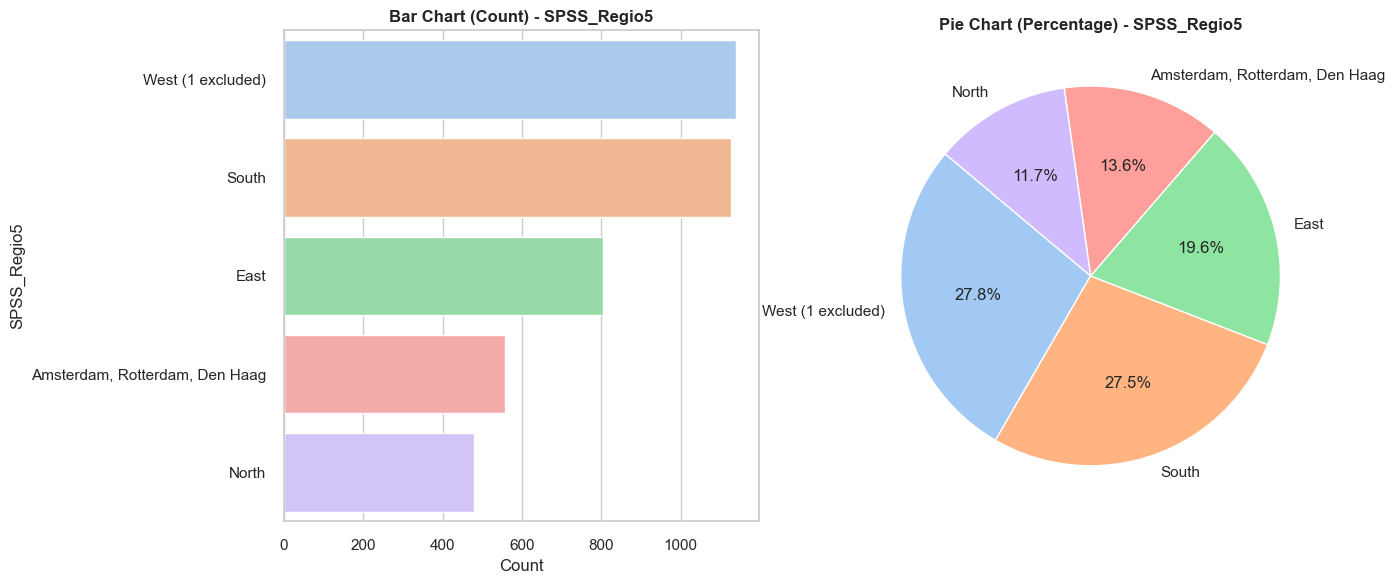


ĐANG PHÂN TÍCH CỘT: 'BAS_huishoudgrootte'
count    4107.000000
mean        1.837594
std         0.588218
min         1.000000
25%         1.000000
50%         2.000000
75%         2.000000
max         4.000000
Name: BAS_huishoudgrootte, dtype: float64


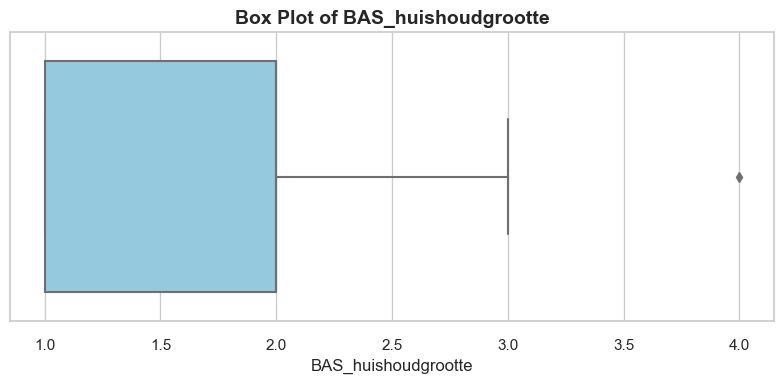


ĐANG PHÂN TÍCH CỘT: 'BAS_werkzaamheid_resp'
Số lượng chi tiết từng nhóm:
BAS_werkzaamheid_resp
(early) retirement           1661
salaried employment          1100
incapacitated                 429
housewife/houseman/other      397
entrepreneur                  165
working for the governent     159
unemployed / job seeker       136
social assistance benefit      58
student/scholar                 2
Name: count, dtype: int64
⚠️ Cột này có 9 nhóm. Chỉ vẽ Bar chart.


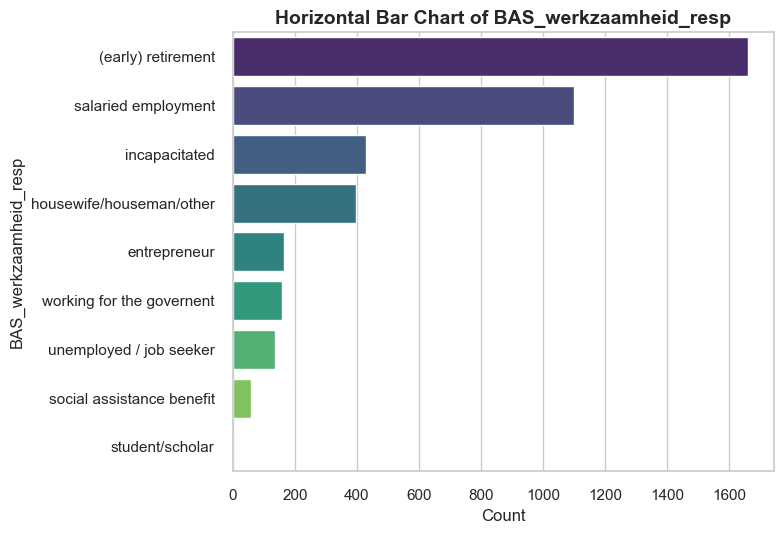


ĐANG PHÂN TÍCH CỘT: 'BAS_bruto_jaarinkomen'
Số lượng chi tiết từng nhóm:
BAS_bruto_jaarinkomen
€12.900 <= 27.000 (below average)                    833
€40.000 <= 67.000 (between 1 and 2 times average)    751
€27.000 <= 33.500 (almost average)                   686
€33.500 <= 40.000 (average)                          672
Don't know / Don't want to say                       640
< €12.900 (minimum)                                  201
€67.000 <= 79.900 (2 times average)                  187
> 79.900 (above 2 times average)                     137
Name: count, dtype: int64
⚠️ Cột này có 8 nhóm. Chỉ vẽ Bar chart.


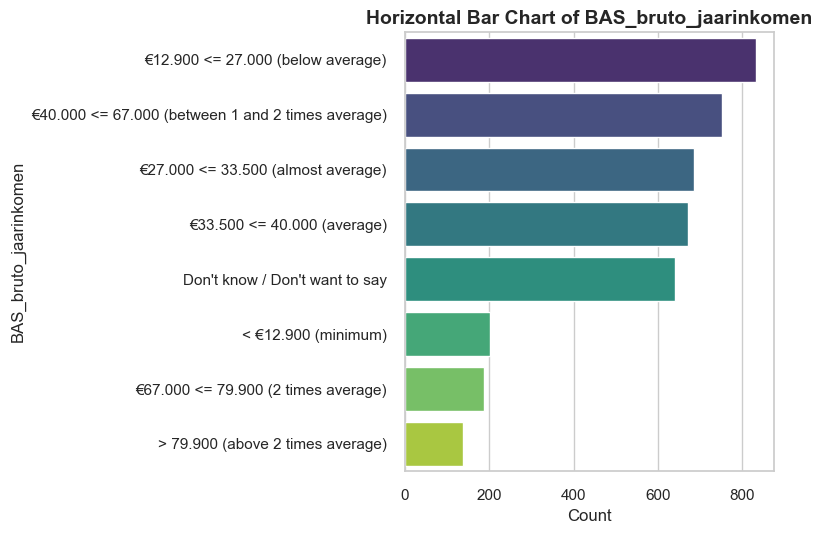


ĐANG PHÂN TÍCH CỘT: 'afg_kinderen_huishouden'
count    4107.000000
mean        0.004870
std         0.069622
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: afg_kinderen_huishouden, dtype: float64


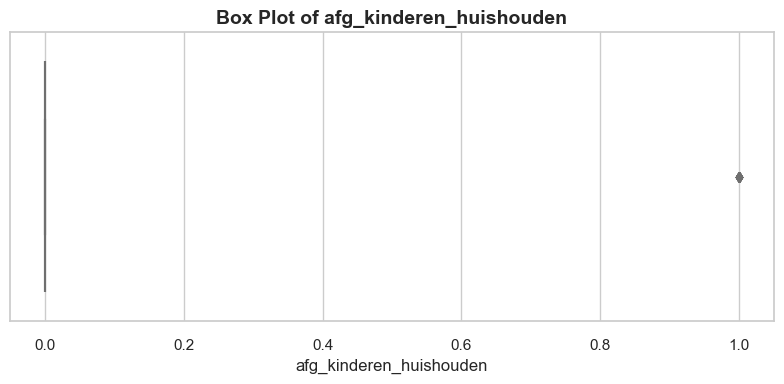


ĐANG PHÂN TÍCH CỘT: 'AFG_sk2015'
Số lượng chi tiết từng nhóm:
AFG_sk2015
d     1056
c      944
b1     914
b2     718
a      475
Name: count, dtype: int64


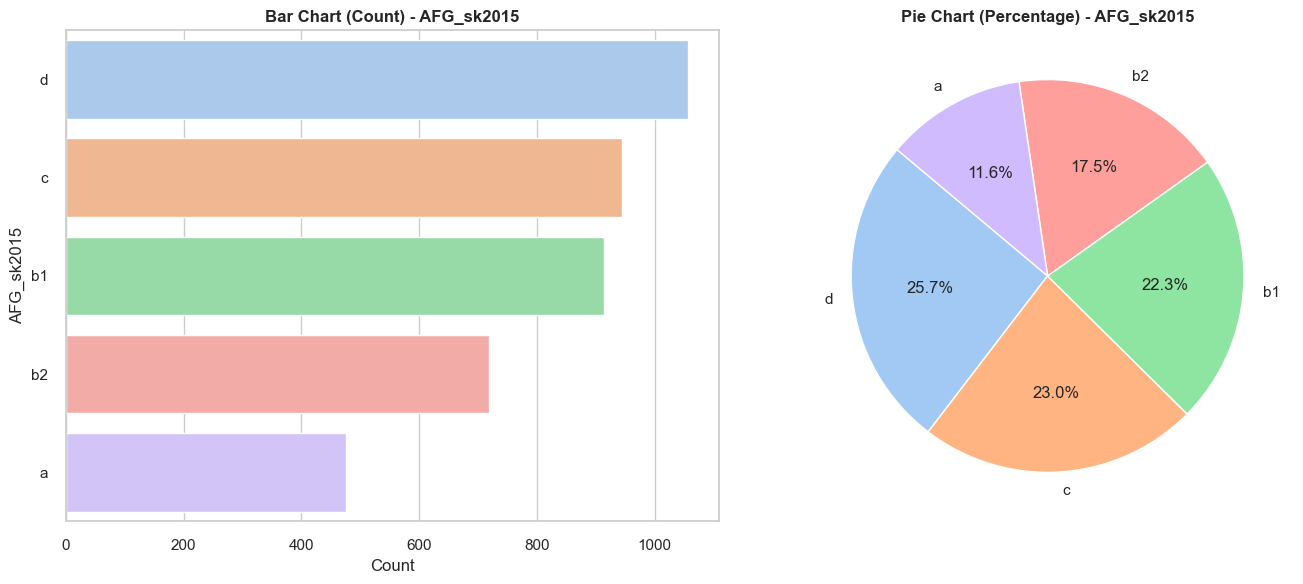


ĐANG PHÂN TÍCH CỘT: 'BAS_voltooide_opleiding8_resp'
Số lượng chi tiết từng nhóm:
BAS_voltooide_opleiding8_resp
MBO 2, 3, 4 of MBO voor 1998                                                           1063
MAVO/ HAVO of VWO (overgegaan naar 4e klas)/ VMBO (theoretisch of gemengd) / (M)ULO     792
LBO / VMBO (kader- of beroepsgericht) / MBO 1 / VBO                                     681
HBO of universitair propedeuse                                                          497
HAVO of VWO (met diploma afgerond) / HBS/ MMS                                           428
HBO of universitair bachelor/kandidaats                                                 240
HBO of universitair master/doctoraal/postdoctoraal                                      191
Geen of basisonderwijs                                                                  127
Name: count, dtype: int64
⚠️ Cột này có 8 nhóm. Chỉ vẽ Bar chart.


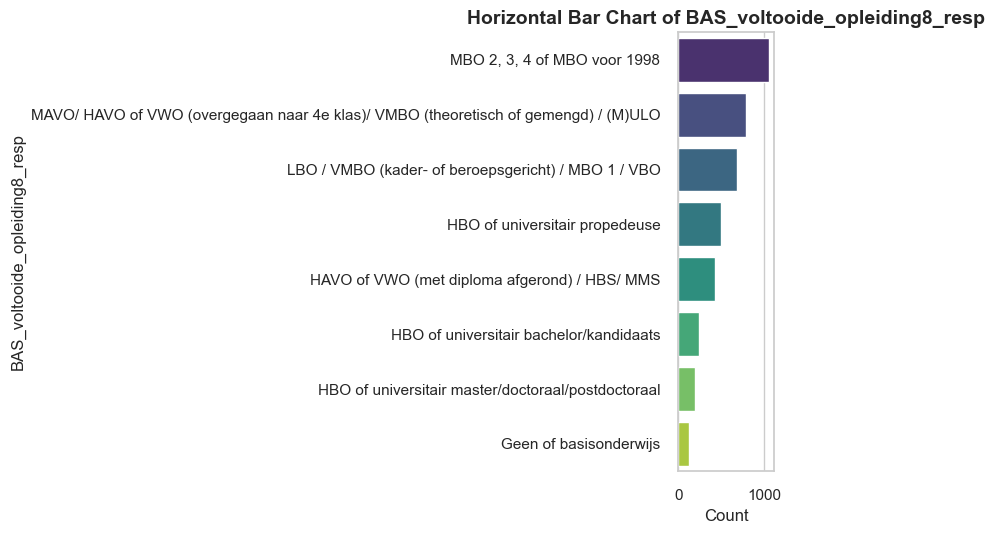


ĐANG PHÂN TÍCH CỘT: 'SPSS_Lifestage'
Số lượng chi tiết từng nhóm:
SPSS_Lifestage
Empty Nesters                       2387
Mature Singles                      1092
Established Families                 355
Single Parents, adult child(ren)     156
Young Couples                         84
Single Parents, child(ren)            15
Mature Families                       12
Young Singles                          5
Young Families                         1
Name: count, dtype: int64
⚠️ Cột này có 9 nhóm. Chỉ vẽ Bar chart.


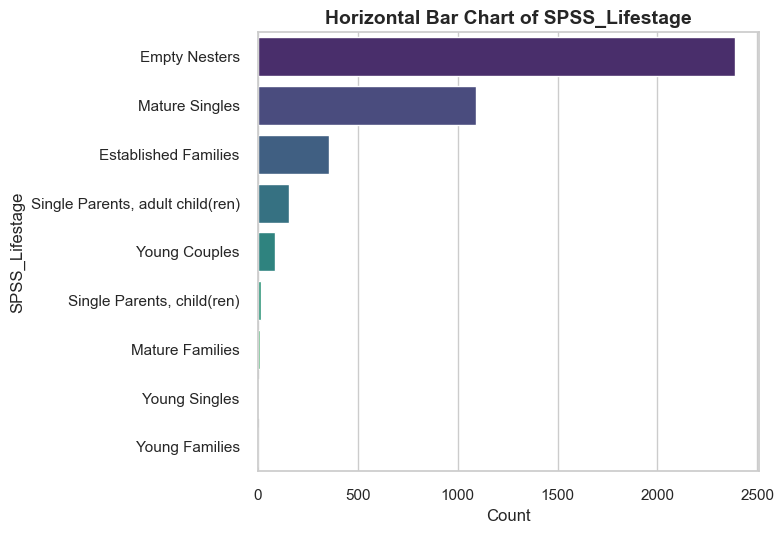


ĐANG PHÂN TÍCH CỘT: 'dbscan_labels'
count    4107.000000
mean        0.131239
std         0.337703
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: dbscan_labels, dtype: float64


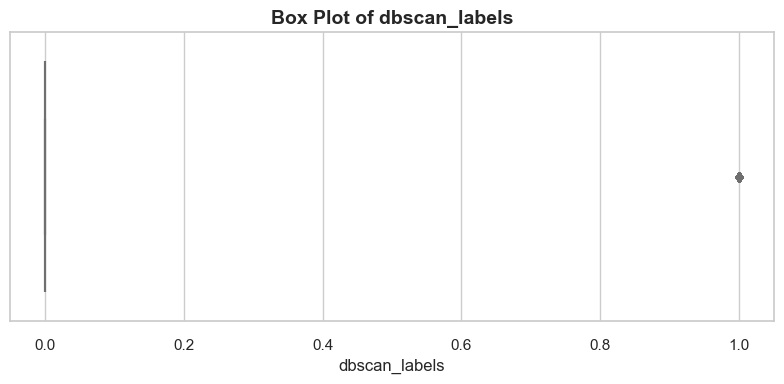


ĐANG PHÂN TÍCH CỘT: 'final_label'
count    4107.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: final_label, dtype: float64


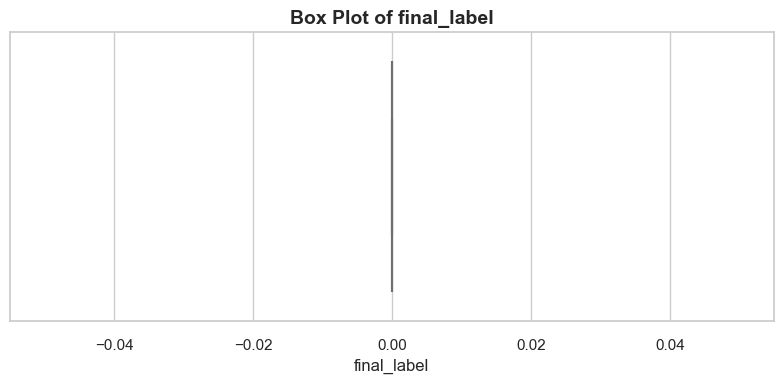

Phân tích bộ dữ liệu: cluster_1

ĐANG PHÂN TÍCH CỘT: 'Unnamed: 0'
count    2533.000000
mean     4721.258981
std      2825.135841
min         5.000000
25%      2279.000000
50%      4641.000000
75%      7172.000000
max      9675.000000
Name: Unnamed: 0, dtype: float64


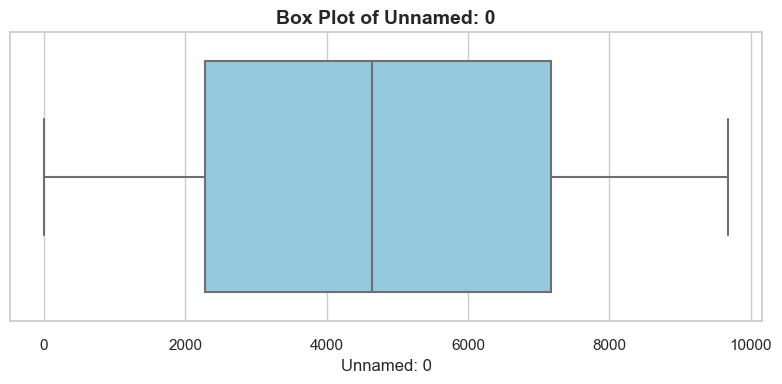


ĐANG PHÂN TÍCH CỘT: 'UserID'
count    2533.000000
mean     4992.850375
std      3016.350093
min         4.000000
25%      2303.000000
50%      4937.000000
75%      7907.000000
max      9675.000000
Name: UserID, dtype: float64


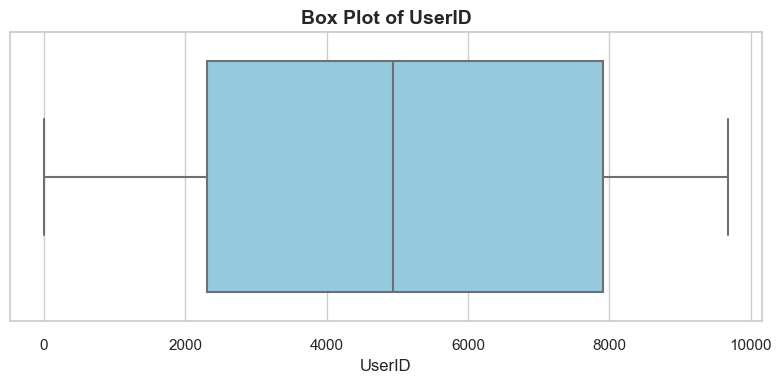


ĐANG PHÂN TÍCH CỘT: 'GenderID'
Số lượng chi tiết từng nhóm:
GenderID
Female    1687
Male       846
Name: count, dtype: int64


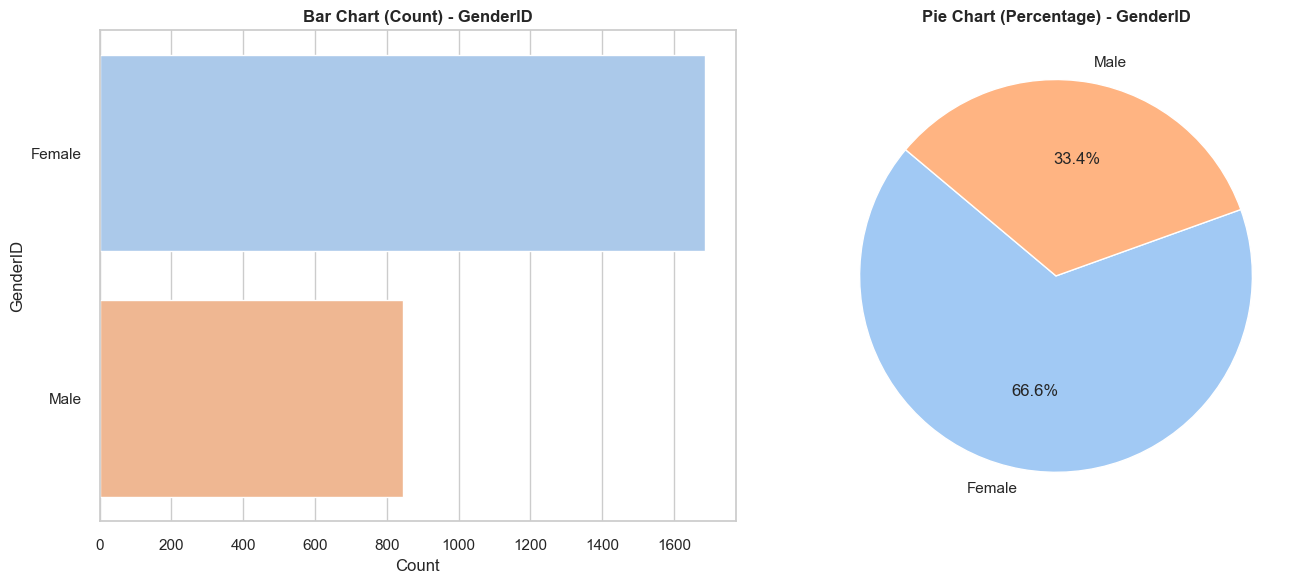


ĐANG PHÂN TÍCH CỘT: 'Age'
count    2533.000000
mean       42.863798
std         8.903556
min        17.000000
25%        37.000000
50%        44.000000
75%        49.000000
max        66.000000
Name: Age, dtype: float64


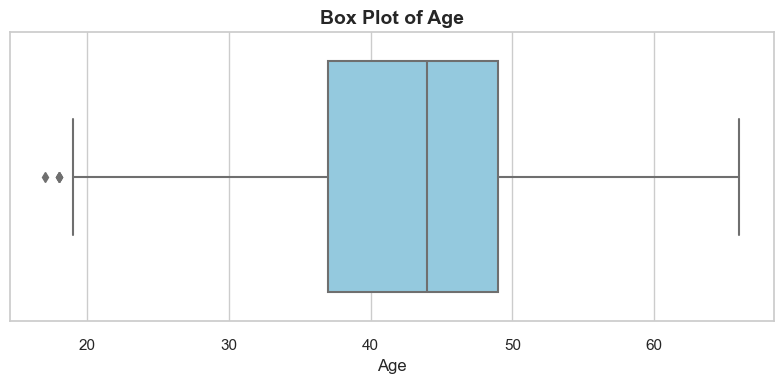


ĐANG PHÂN TÍCH CỘT: 'SPSS_Regio5'
Số lượng chi tiết từng nhóm:
SPSS_Regio5
West (1 excluded)                 755
South                             686
East                              603
North                             308
Amsterdam, Rotterdam, Den Haag    181
Name: count, dtype: int64


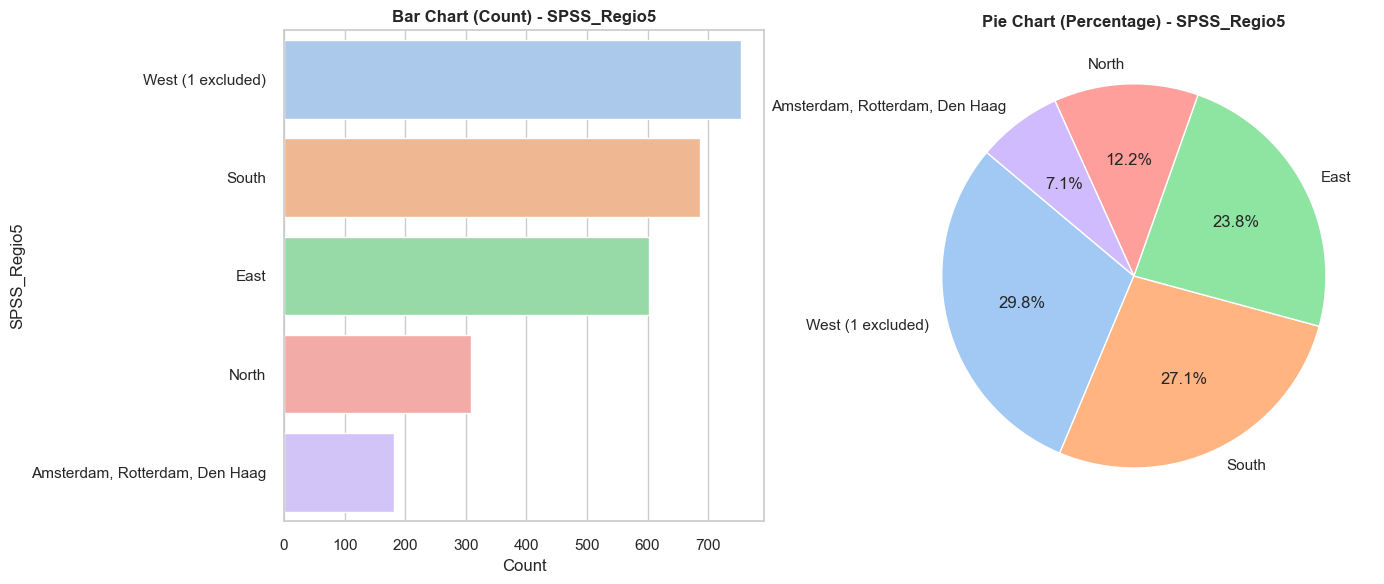


ĐANG PHÂN TÍCH CỘT: 'BAS_huishoudgrootte'
count    2533.000000
mean        3.824319
std         0.755920
min         2.000000
25%         3.000000
50%         4.000000
75%         4.000000
max         6.000000
Name: BAS_huishoudgrootte, dtype: float64


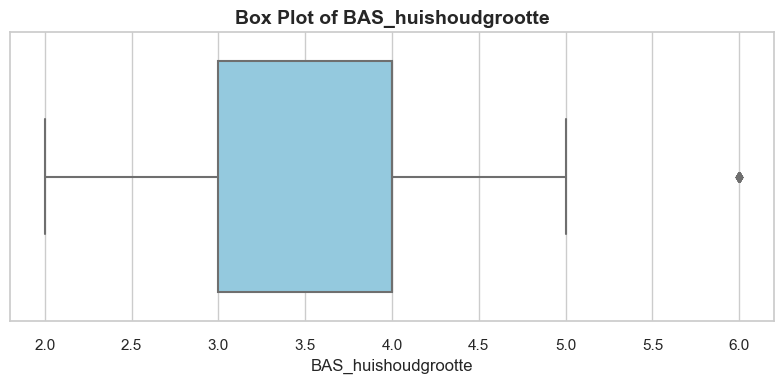


ĐANG PHÂN TÍCH CỘT: 'BAS_werkzaamheid_resp'
Số lượng chi tiết từng nhóm:
BAS_werkzaamheid_resp
salaried employment          1653
entrepreneur                  206
housewife/houseman/other      192
working for the governent     176
incapacitated                 127
student/scholar                88
unemployed / job seeker        71
social assistance benefit      16
(early) retirement              4
Name: count, dtype: int64
⚠️ Cột này có 9 nhóm. Chỉ vẽ Bar chart.


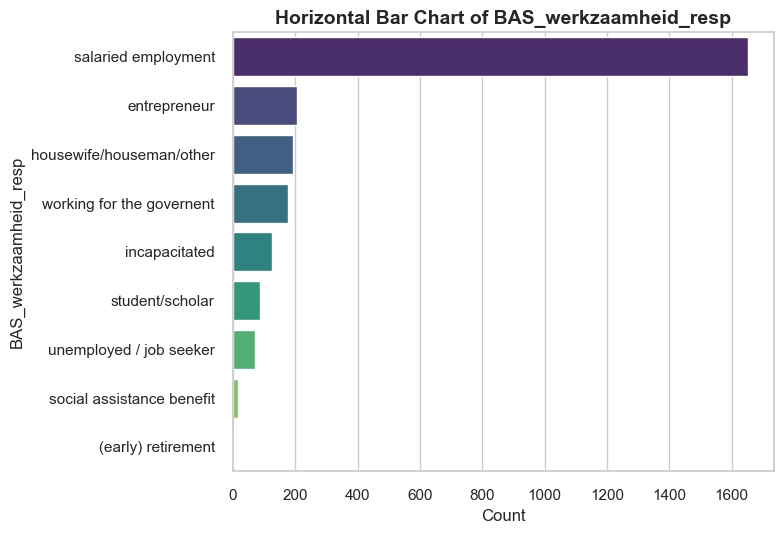


ĐANG PHÂN TÍCH CỘT: 'BAS_bruto_jaarinkomen'
Số lượng chi tiết từng nhóm:
BAS_bruto_jaarinkomen
€40.000 <= 67.000 (between 1 and 2 times average)    698
Don't know / Don't want to say                       474
€33.500 <= 40.000 (average)                          427
€27.000 <= 33.500 (almost average)                   245
€12.900 <= 27.000 (below average)                    242
€67.000 <= 79.900 (2 times average)                  241
> 79.900 (above 2 times average)                     143
< €12.900 (minimum)                                   63
Name: count, dtype: int64
⚠️ Cột này có 8 nhóm. Chỉ vẽ Bar chart.


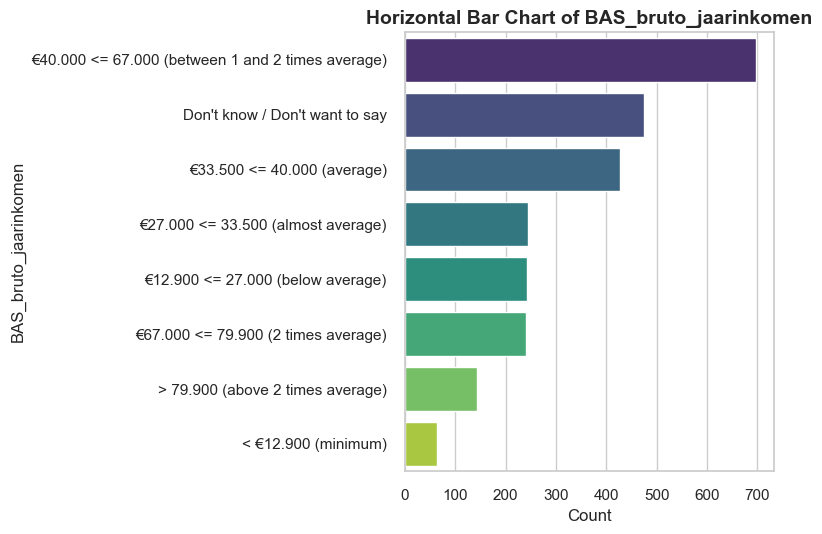


ĐANG PHÂN TÍCH CỘT: 'afg_kinderen_huishouden'
count    2533.000000
mean        1.328464
std         0.946582
min         0.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         4.000000
Name: afg_kinderen_huishouden, dtype: float64


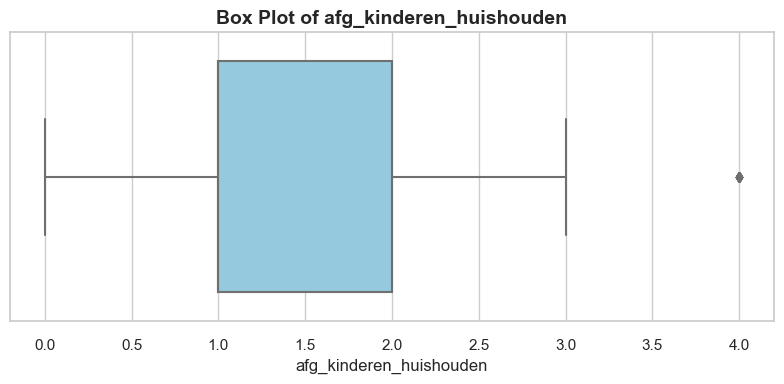


ĐANG PHÂN TÍCH CỘT: 'AFG_sk2015'
Số lượng chi tiết từng nhóm:
AFG_sk2015
b1    752
a     666
b2    625
c     352
d     138
Name: count, dtype: int64


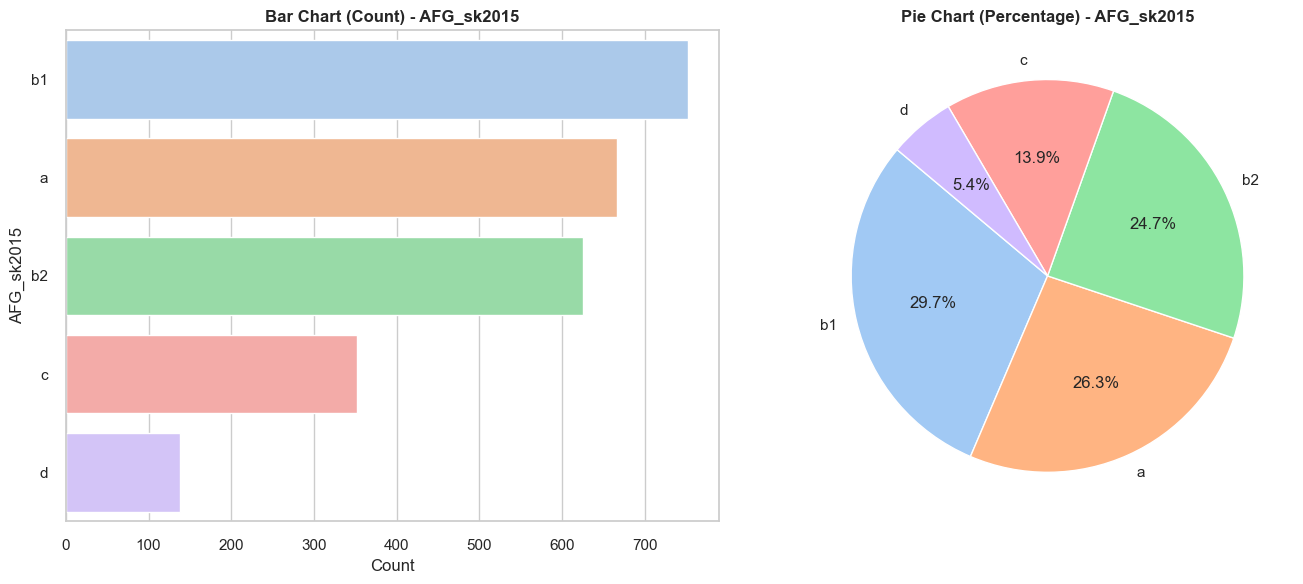


ĐANG PHÂN TÍCH CỘT: 'BAS_voltooide_opleiding8_resp'
Số lượng chi tiết từng nhóm:
BAS_voltooide_opleiding8_resp
MBO 2, 3, 4 of MBO voor 1998                                                           909
HBO of universitair propedeuse                                                         354
HBO of universitair bachelor/kandidaats                                                331
HAVO of VWO (met diploma afgerond) / HBS/ MMS                                          242
HBO of universitair master/doctoraal/postdoctoraal                                     208
LBO / VMBO (kader- of beroepsgericht) / MBO 1 / VBO                                    176
MAVO/ HAVO of VWO (overgegaan naar 4e klas)/ VMBO (theoretisch of gemengd) / (M)ULO    175
Geen of basisonderwijs                                                                   4
Name: count, dtype: int64
⚠️ Cột này có 8 nhóm. Chỉ vẽ Bar chart.


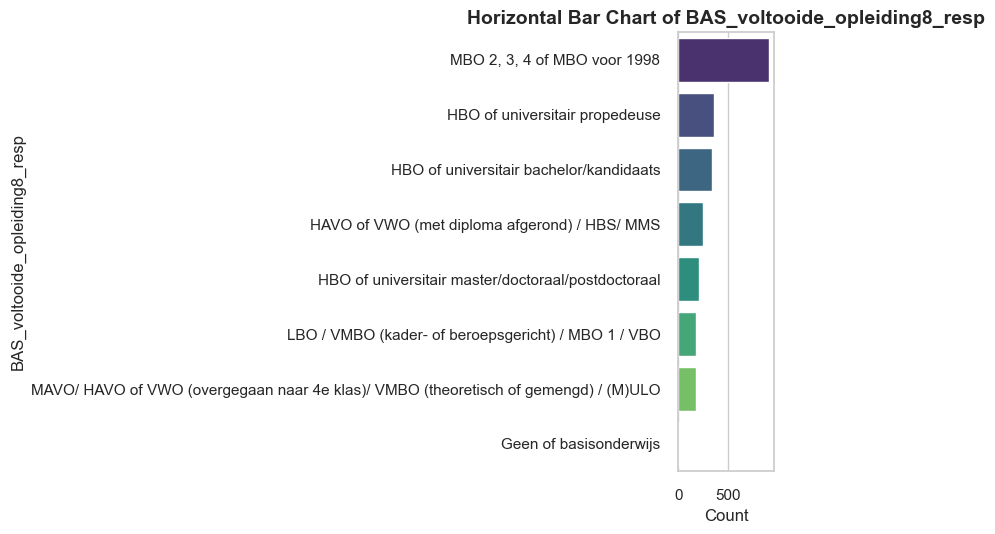


ĐANG PHÂN TÍCH CỘT: 'SPSS_Lifestage'
Số lượng chi tiết từng nhóm:
SPSS_Lifestage
Mature Families                     1025
Established Families                 563
Young Families                       417
Single Parents, child(ren)           389
Single Parents, adult child(ren)     139
Name: count, dtype: int64


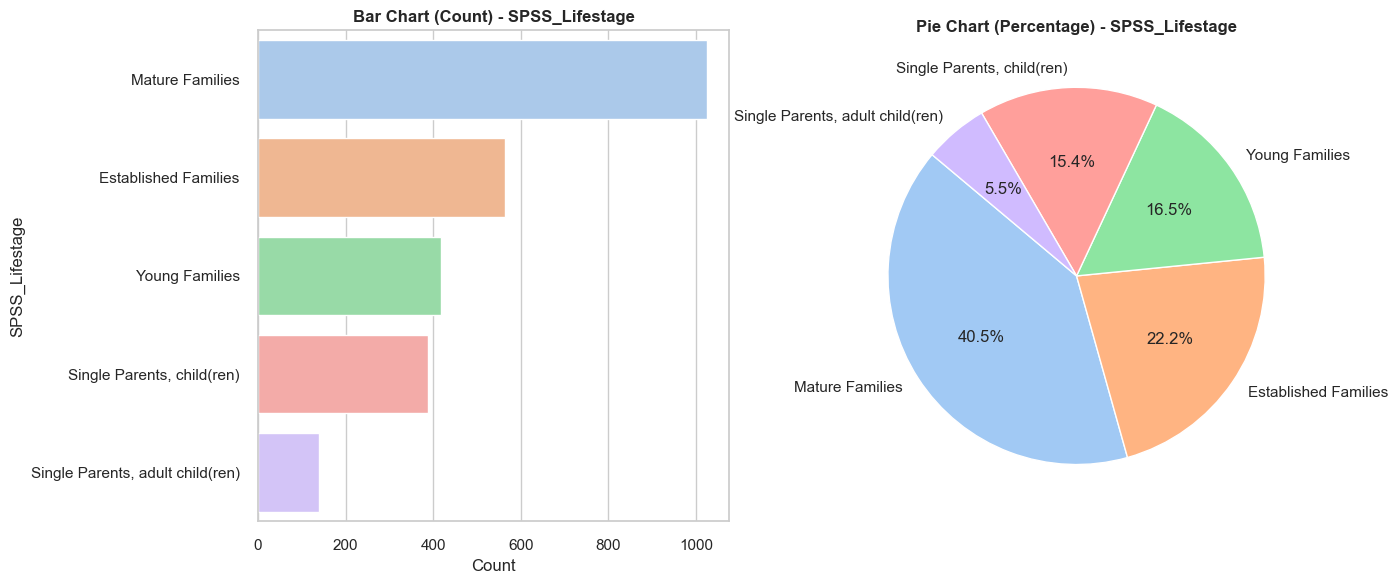


ĐANG PHÂN TÍCH CỘT: 'dbscan_labels'
count    2533.000000
mean        1.009080
std         0.094875
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         2.000000
Name: dbscan_labels, dtype: float64


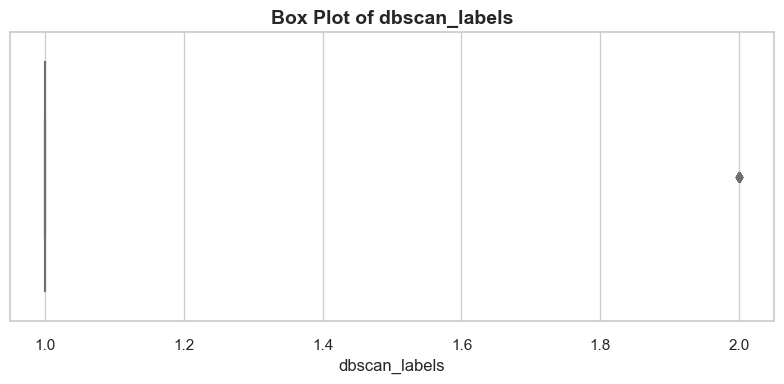


ĐANG PHÂN TÍCH CỘT: 'final_label'
count    2533.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
Name: final_label, dtype: float64


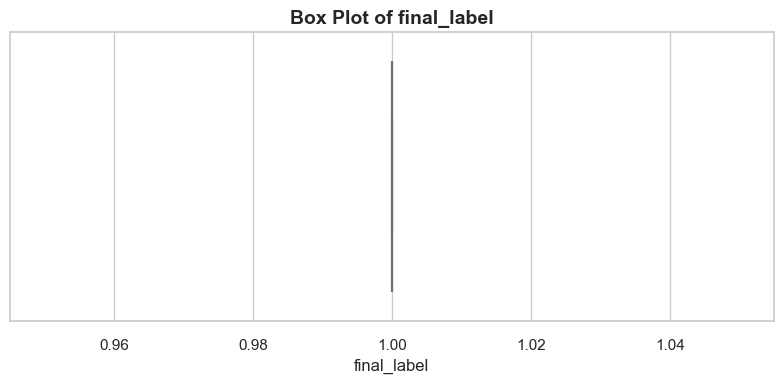

Phân tích bộ dữ liệu: cluster_2

ĐANG PHÂN TÍCH CỘT: 'Unnamed: 0'
count    1167.000000
mean     4497.984576
std      2805.103251
min        19.000000
25%      2135.000000
50%      4089.000000
75%      6762.000000
max      9672.000000
Name: Unnamed: 0, dtype: float64


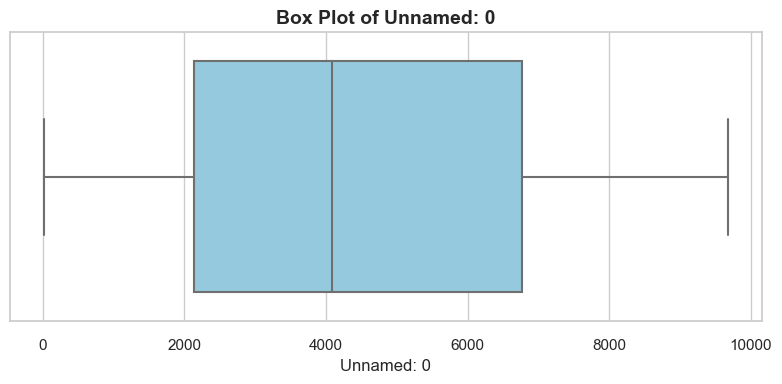


ĐANG PHÂN TÍCH CỘT: 'UserID'
count    1167.000000
mean     3884.941731
std      2494.625300
min        15.000000
25%      1796.000000
50%      3617.000000
75%      5803.000000
max      9676.000000
Name: UserID, dtype: float64


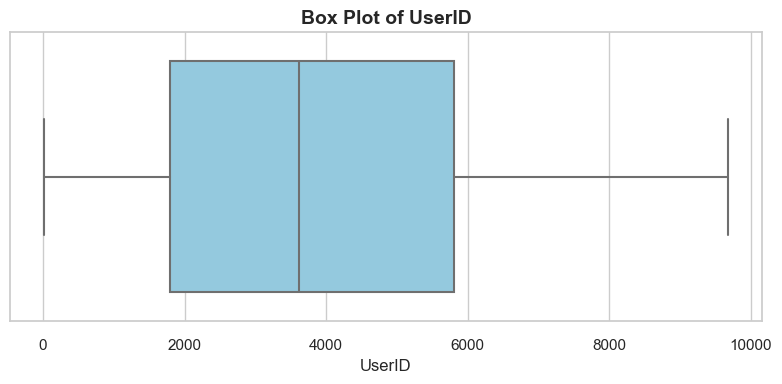


ĐANG PHÂN TÍCH CỘT: 'GenderID'
Số lượng chi tiết từng nhóm:
GenderID
Female    756
Male      411
Name: count, dtype: int64


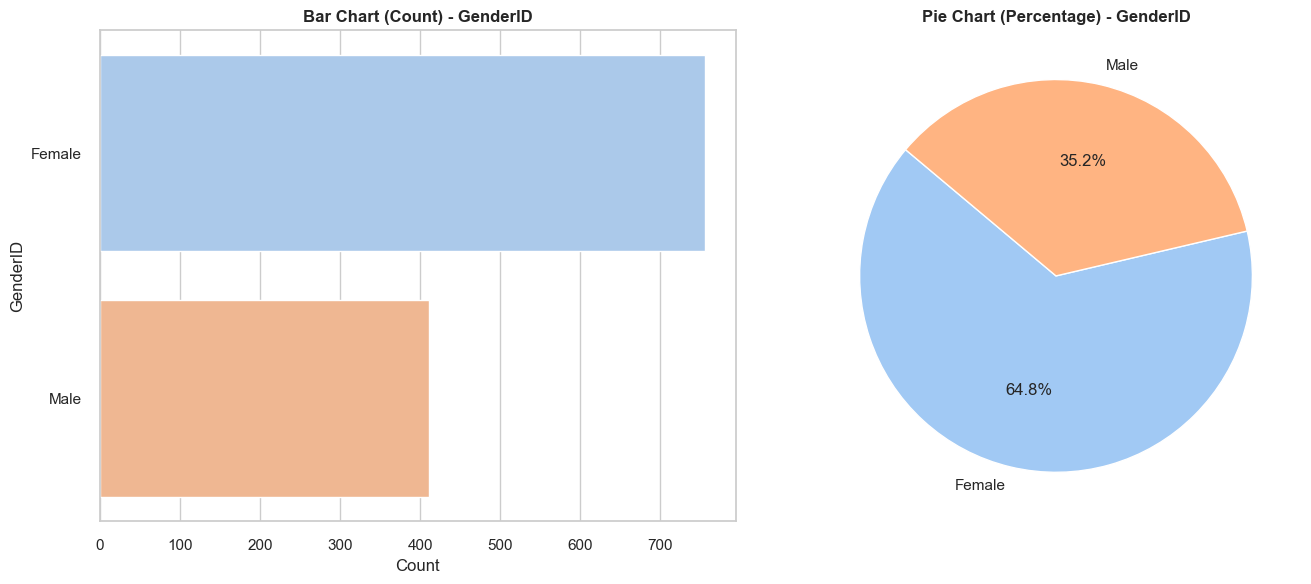


ĐANG PHÂN TÍCH CỘT: 'Age'
count    1167.000000
mean       33.070266
std         6.895212
min        19.000000
25%        28.000000
50%        32.000000
75%        38.000000
max        54.000000
Name: Age, dtype: float64


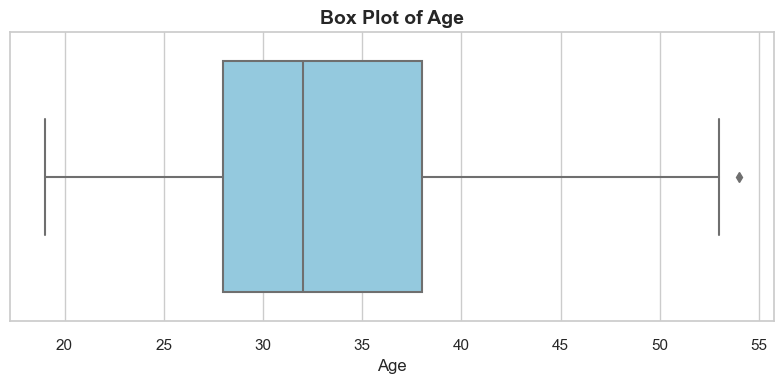


ĐANG PHÂN TÍCH CỘT: 'SPSS_Regio5'
Số lượng chi tiết từng nhóm:
SPSS_Regio5
West (1 excluded)                 367
East                              267
South                             245
Amsterdam, Rotterdam, Den Haag    150
North                             138
Name: count, dtype: int64


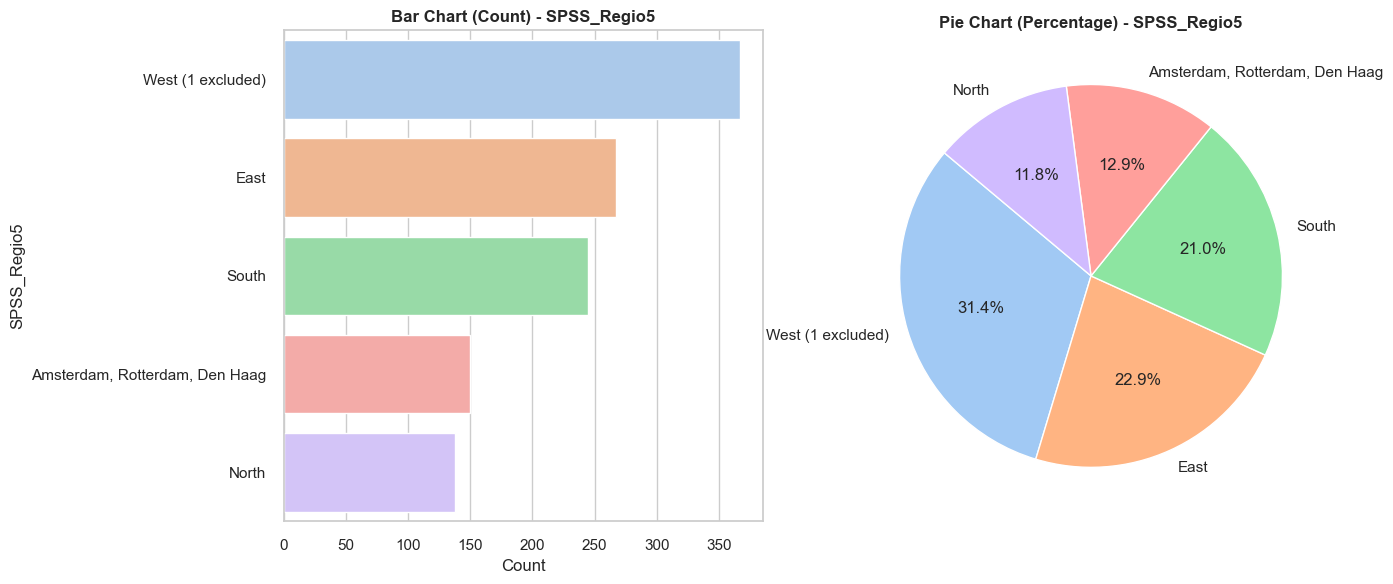


ĐANG PHÂN TÍCH CỘT: 'BAS_huishoudgrootte'
count    1167.000000
mean        1.479863
std         0.499809
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         2.000000
Name: BAS_huishoudgrootte, dtype: float64


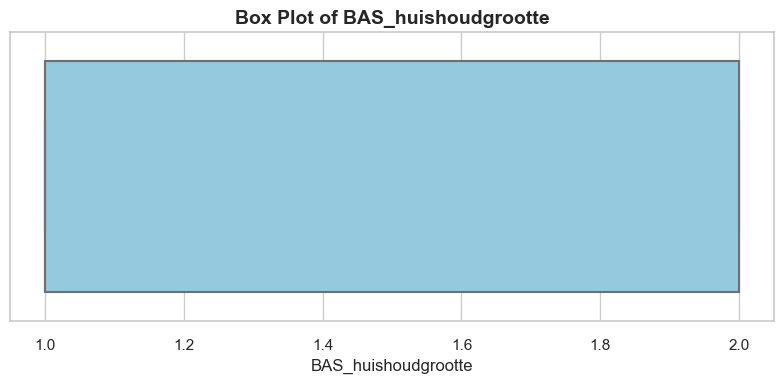


ĐANG PHÂN TÍCH CỘT: 'BAS_werkzaamheid_resp'
Số lượng chi tiết từng nhóm:
BAS_werkzaamheid_resp
salaried employment          737
student/scholar              137
working for the governent    102
incapacitated                 72
entrepreneur                  51
unemployed / job seeker       39
social assistance benefit     18
housewife/houseman/other      11
Name: count, dtype: int64
⚠️ Cột này có 8 nhóm. Chỉ vẽ Bar chart.


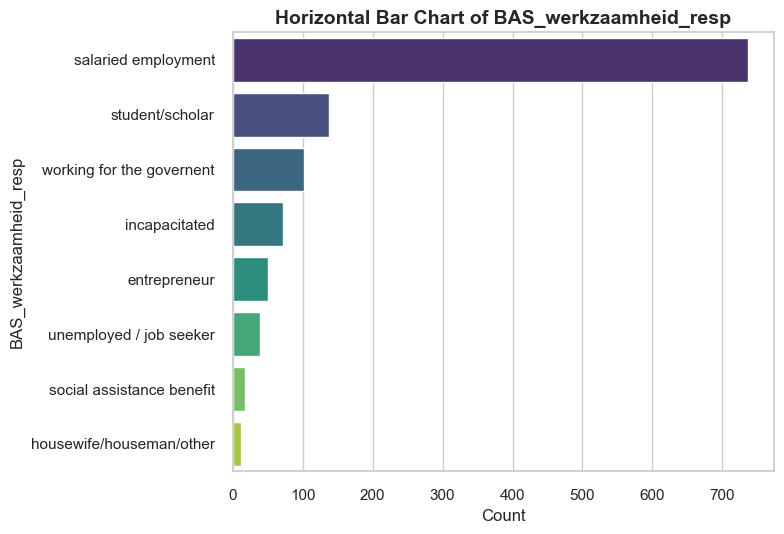


ĐANG PHÂN TÍCH CỘT: 'BAS_bruto_jaarinkomen'
Số lượng chi tiết từng nhóm:
BAS_bruto_jaarinkomen
€40.000 <= 67.000 (between 1 and 2 times average)    232
€12.900 <= 27.000 (below average)                    210
€33.500 <= 40.000 (average)                          187
< €12.900 (minimum)                                  166
Don't know / Don't want to say                       152
€27.000 <= 33.500 (almost average)                   127
€67.000 <= 79.900 (2 times average)                   62
> 79.900 (above 2 times average)                      31
Name: count, dtype: int64
⚠️ Cột này có 8 nhóm. Chỉ vẽ Bar chart.


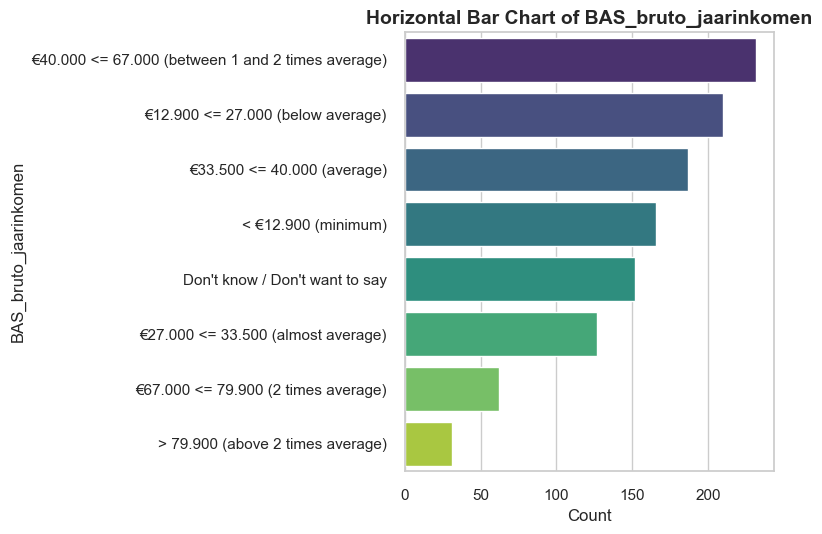


ĐANG PHÂN TÍCH CỘT: 'afg_kinderen_huishouden'
count    1167.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: afg_kinderen_huishouden, dtype: float64


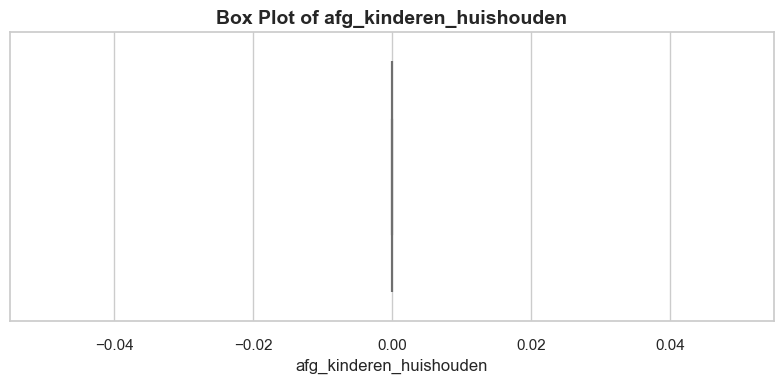


ĐANG PHÂN TÍCH CỘT: 'AFG_sk2015'
Số lượng chi tiết từng nhóm:
AFG_sk2015
b1    382
a     345
b2    298
c     106
d      36
Name: count, dtype: int64


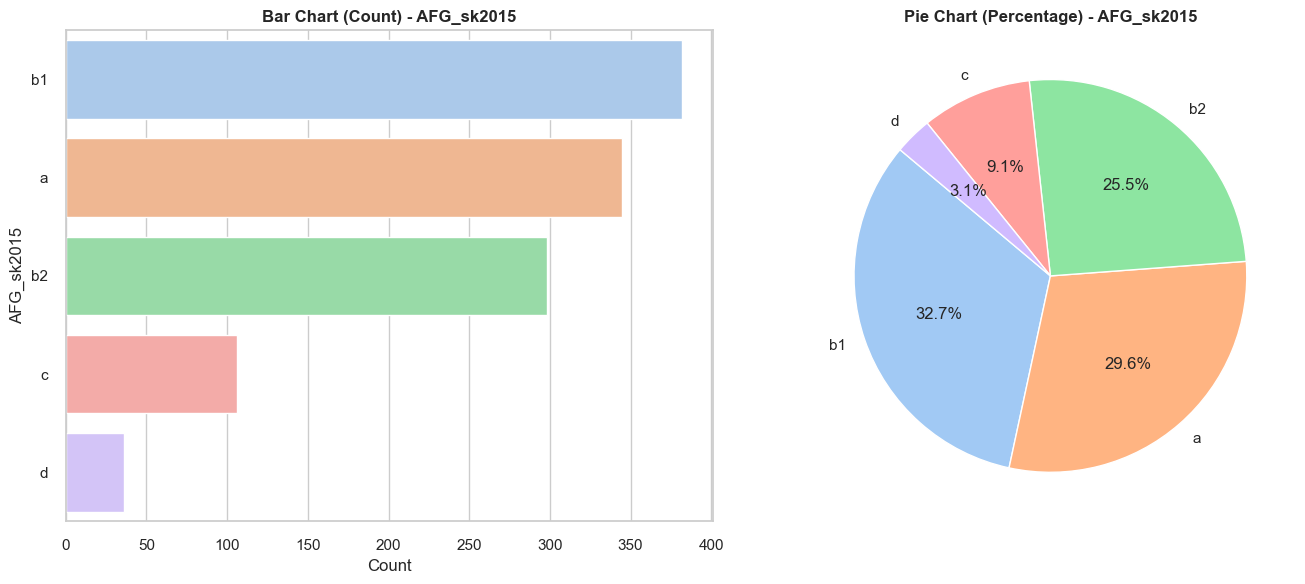


ĐANG PHÂN TÍCH CỘT: 'BAS_voltooide_opleiding8_resp'
Số lượng chi tiết từng nhóm:
BAS_voltooide_opleiding8_resp
MBO 2, 3, 4 of MBO voor 1998                                                           272
HBO of universitair bachelor/kandidaats                                                270
HBO of universitair master/doctoraal/postdoctoraal                                     218
HBO of universitair propedeuse                                                         190
HAVO of VWO (met diploma afgerond) / HBS/ MMS                                           73
MAVO/ HAVO of VWO (overgegaan naar 4e klas)/ VMBO (theoretisch of gemengd) / (M)ULO     24
LBO / VMBO (kader- of beroepsgericht) / MBO 1 / VBO                                     23
Geen of basisonderwijs                                                                  10
Name: count, dtype: int64
⚠️ Cột này có 8 nhóm. Chỉ vẽ Bar chart.


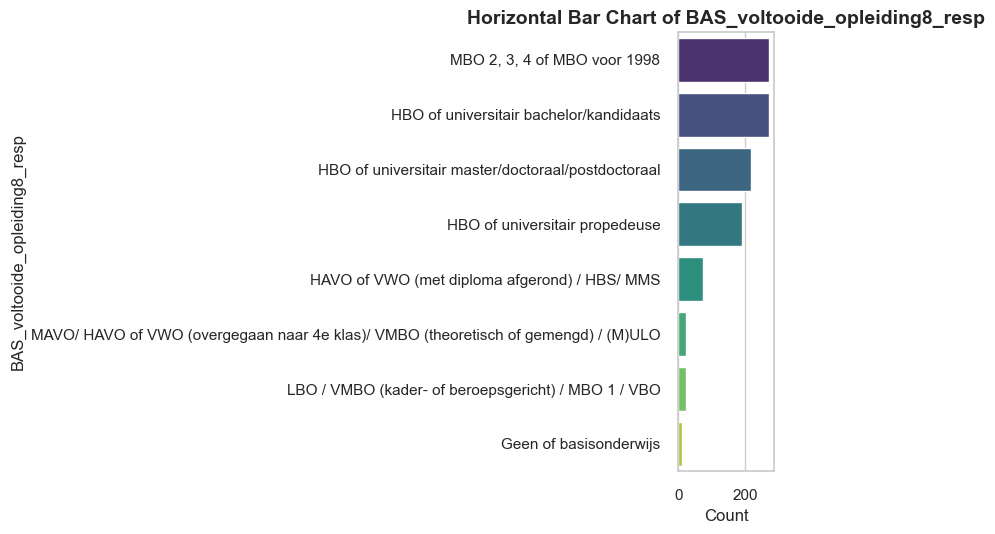


ĐANG PHÂN TÍCH CỘT: 'SPSS_Lifestage'
Số lượng chi tiết từng nhóm:
SPSS_Lifestage
Young Couples     550
Young Singles     537
Mature Singles     70
Empty Nesters      10
Name: count, dtype: int64


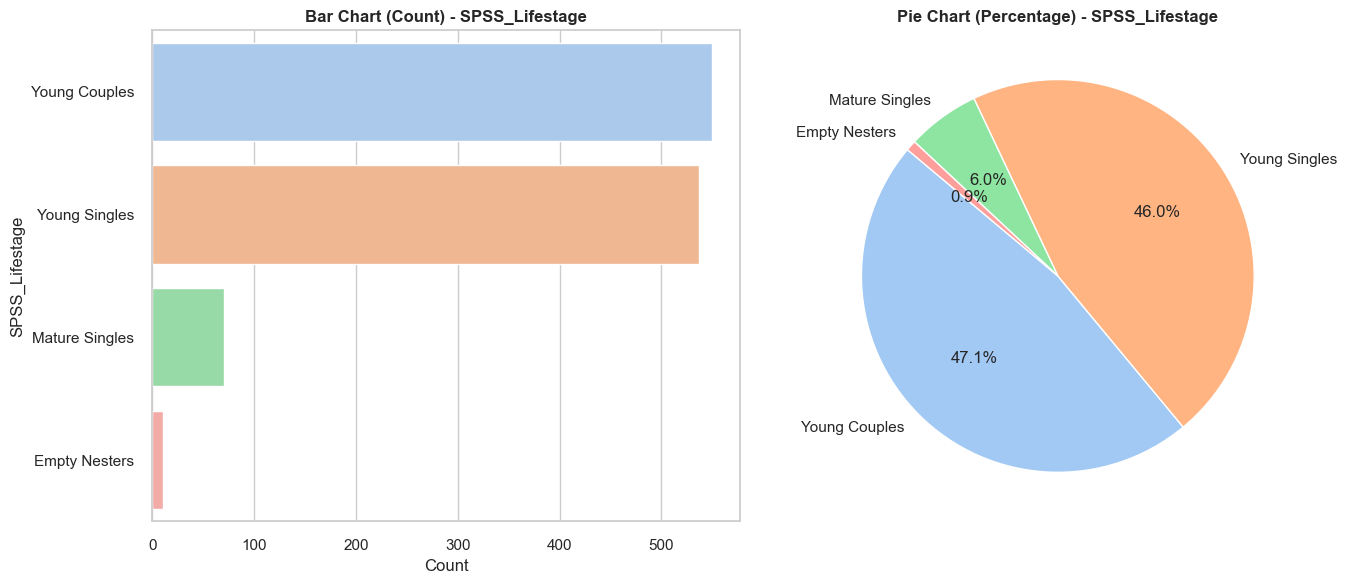


ĐANG PHÂN TÍCH CỘT: 'dbscan_labels'
count    1167.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: dbscan_labels, dtype: float64


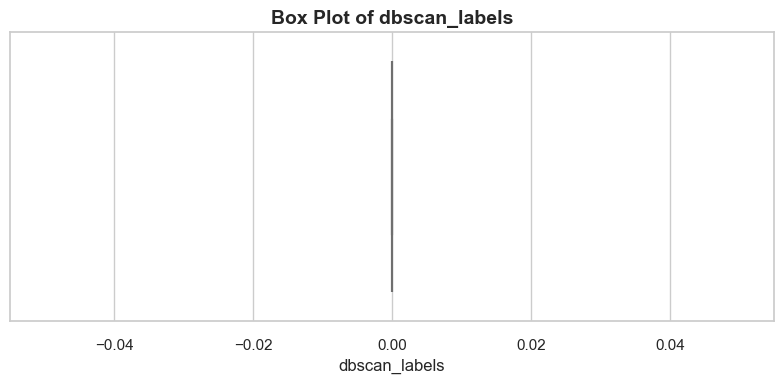


ĐANG PHÂN TÍCH CỘT: 'final_label'
count    1167.0
mean        2.0
std         0.0
min         2.0
25%         2.0
50%         2.0
75%         2.0
max         2.0
Name: final_label, dtype: float64


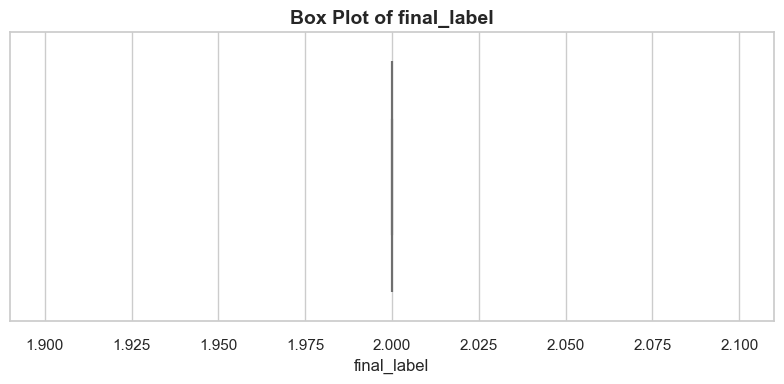

In [24]:
for k, v in cluster_dict.items():
    print(f"Phân tích bộ dữ liệu: {k}")
    analyze_and_plot_df(v)
    print("="*100)

In [7]:
output_profiling = "../../resources/profiling"

for k, v in cluster_dict.items():
    labeled_user_data_output_filename = f"Labeled_user_data_profiling_{k}.html"
    labeled_user_data_dashboard_title = f"Labeled User {k} Dataset Profiling"
    data_profiling(v, output_profiling, labeled_user_data_output_filename, labeled_user_data_dashboard_title)

Running Profile Report...


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 14/14 [00:00<00:00, 285.72it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

...


100%|██████████| 14/14 [00:00<00:00, 259.26it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Open report: D:\MASTER\2.1. ADM\ctmj\resources\profiling\Labeled_user_data_profiling_cluster_2.html
